<a href="https://colab.research.google.com/github/CatalinaDeras24/CLAVE-G/blob/main/Notebook/Agrupacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd

In [81]:
import numpy as np

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos

In [63]:
url="https://raw.githubusercontent.com/CatalinaDeras24/CLAVE-G/refs/heads/main/data/clave_G_agrupacion.csv"

In [64]:
df=pd.read_csv(url)

In [65]:
print(df.head())

  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     G-R0007    33       631            3.98           15.70          6.07   
1     G-R0123    44       995            6.13           75.82          7.87   
2     G-R0009    28       509            1.30           30.45          5.97   
3     G-R0228    46       769            2.94           69.77          5.28   
4     G-R0106    37      1069            5.56           83.50          8.27   

   reclamos  antiguedad_meses  
0         3                 1  
1         2                32  
2         5                 1  
3        12                21  
4         1                 8  


# Seleccionar variables adecuadas para clustering.

In [66]:
print(df.isnull().sum())

registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64


In [67]:
df= df.dropna()

In [68]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

print(variables_numericas.columns)

Index(['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion',
       'reclamos', 'antiguedad_meses'],
      dtype='object')


In [69]:
X = variables_numericas

JUSTIFICACION : Se seleccionaron ya que representan características numéricas relevantes del comportamiento y perfil de cada registro

# Normalizar o escalar los datos correctamente

In [70]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.69483613 -1.02386869 -0.52890544 -1.41895085 -0.46325771  0.2552171
  -1.33476049]
 [ 0.42163555 -0.2179496   0.20982383 -0.19280784  0.43006699 -0.20272564
   0.94249131]
 [-1.20232326 -1.29398442 -1.44974006 -1.11812568 -0.51288686  1.17110259
  -1.33476049]
 [ 0.6246304  -0.71832794 -0.88624425 -0.31619714 -0.85532799  4.37670179
   0.13443422]
 [-0.28884643 -0.05410891  0.01397467 -0.0361748   0.62858358 -0.66066838
  -0.82054234]]


#Aplicar metodo del codo

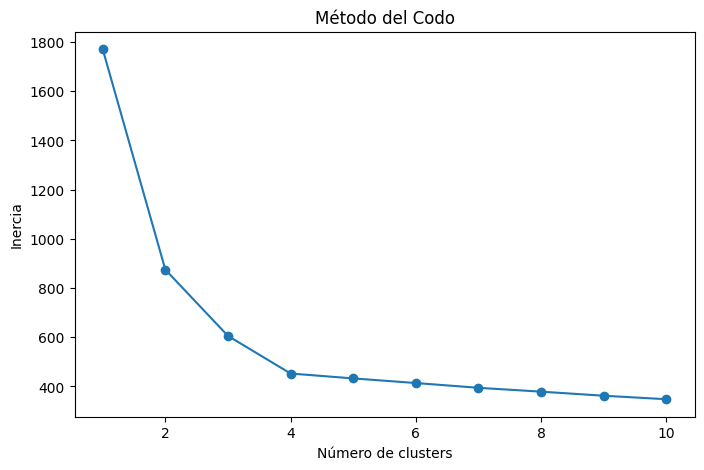

In [71]:
inercias = []

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercias.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1, 11), inercias, marker='o')

plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')

plt.show()

# Aplicar K-Means

In [74]:
n_clusters = 4

In [76]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

#Agregar la columna del grupo o cluster al dataset original

In [77]:
df['cluster'] = kmeans.labels_

In [78]:
print(df.head())

  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     G-R0007    33       631            3.98           15.70          6.07   
1     G-R0123    44       995            6.13           75.82          7.87   
2     G-R0009    28       509            1.30           30.45          5.97   
3     G-R0228    46       769            2.94           69.77          5.28   
4     G-R0106    37      1069            5.56           83.50          8.27   

   reclamos  antiguedad_meses  cluster  
0         3                 1        3  
1         2                32        2  
2         5                 1        3  
3        12                21        0  
4         1                 8        2  


#Visualizar los grupos mediante gráficos

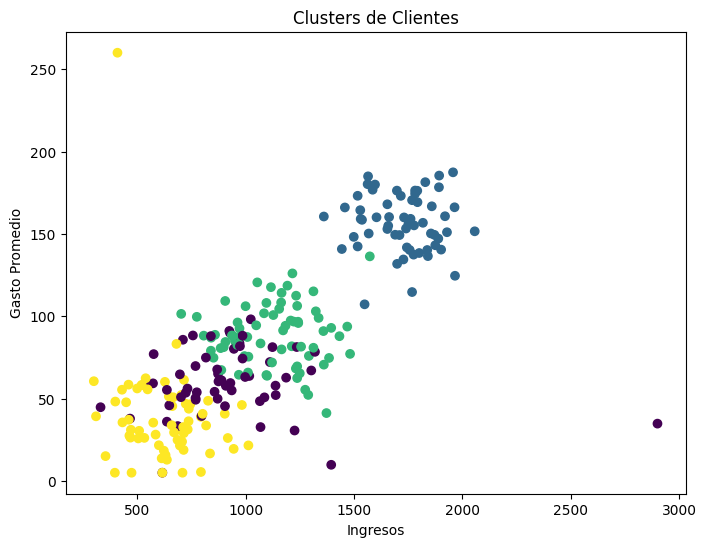

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['ingresos'],
    df['gasto_promedio'],
    c=df['cluster']
)

plt.xlabel('Ingresos')
plt.ylabel('Gasto Promedio')
plt.title('Clusters de Clientes')

plt.show()